In [2]:
#出力ファイルを一つにまとめる
import os
import re

folder_path = os.getcwd()
all_extracted_data = []

# 各ファイル内のすべての行を対象に処理
for filename in os.listdir(folder_path):
    if filename.endswith('.lst'):
        filepath = os.path.join(folder_path, filename)
        with open(filepath, 'r', encoding='utf-8') as f:
            lines = f.readlines()
            base_name = os.path.splitext(filename)[0]
            match = re.search(r'P=(\d+)', base_name)
            if match:
                param = match.group(1)
                for line in lines:
                    line = line.strip()
                    combined_line = f'{param}\t{line}'
                    all_extracted_data.append(combined_line)

# paramでソート（1列目がparam）
sorted_data = sorted(all_extracted_data, key=lambda x: int(x.split('\t')[0]))

# すべてを一つのファイルに出力
output_file = 'all_pg_combined.lst'
with open(output_file, 'w', encoding='utf-8') as f_out:
    for line in sorted_data:
        f_out.write(line + '\n')

print(f'出力完了: {output_file}')


出力完了: all_pg_combined.lst


In [3]:
#p_gの値でファイルに分割する
from collections import defaultdict

# 入力ファイル
input_file = 'all_pg_combined.lst'

# 2列目の値ごとの行を保存する辞書
grouped_lines = defaultdict(list)

# ファイルを読み込んで、2列目の値でグループ化
with open(input_file, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            key = parts[1]  # 2列目（インデックス1）の値
            grouped_lines[key].append(line.strip())

# 各グループを別ファイルに出力
for key, lines in grouped_lines.items():
    # 小数点を含む場合に備えてファイル名として安全に変換
    safe_key = key.replace('.', '_')
    output_filename = f'pg={safe_key}.lst'
    with open(output_filename, 'w', encoding='utf-8') as f_out:
        for line in lines:
            f_out.write(line + '\n')

print("出力完了: 2列目の値ごとにファイルを分割しました。")


出力完了: 2列目の値ごとにファイルを分割しました。


In [4]:
from collections import defaultdict
import os

# 対象ファイルの接頭辞と拡張子
prefix = "pg="
suffix = ".lst"

# 処理したいファイル名リスト（必要に応じて追加）
targets = ["0_0","0_1","0_2","0_3","0_4","0_5","0_6","0_7","0_8","0_9","1_0"]  # ここを自由に増やせます

for target in targets:
    filename = f"{prefix}{target}{suffix}"
    output_filename = f"averaged_{filename}"

    # ファイルが存在するか確認
    if not os.path.exists(filename):
        print(f"スキップ: ファイル {filename} が存在しません。")
        continue

    grouped = defaultdict(list)

    # ファイル読み込み＆グループ分け
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            cols = line.strip().split('\t')
            if len(cols) < 3:
                continue  # 空行や不正行をスキップ
            try:
                key = int(cols[0])
                val = float(cols[2])
                grouped[key].append(val)
            except ValueError:
                continue  # 数値変換に失敗した場合スキップ

    # 平均値計算とファイル書き込み
    with open(output_filename, 'w', encoding='utf-8') as f_out:
        for key in sorted(grouped.keys()):
            avg_val = sum(grouped[key]) / len(grouped[key])
            f_out.write(f"{key}\t{avg_val:.6f}\n")

    print(f"→ 平均結果を '{output_filename}' に書き出しました。")


→ 平均結果を 'averaged_pg=0_0.lst' に書き出しました。
→ 平均結果を 'averaged_pg=0_1.lst' に書き出しました。
→ 平均結果を 'averaged_pg=0_2.lst' に書き出しました。
→ 平均結果を 'averaged_pg=0_3.lst' に書き出しました。
→ 平均結果を 'averaged_pg=0_4.lst' に書き出しました。
→ 平均結果を 'averaged_pg=0_5.lst' に書き出しました。
→ 平均結果を 'averaged_pg=0_6.lst' に書き出しました。
→ 平均結果を 'averaged_pg=0_7.lst' に書き出しました。
→ 平均結果を 'averaged_pg=0_8.lst' に書き出しました。
→ 平均結果を 'averaged_pg=0_9.lst' に書き出しました。
→ 平均結果を 'averaged_pg=1_0.lst' に書き出しました。


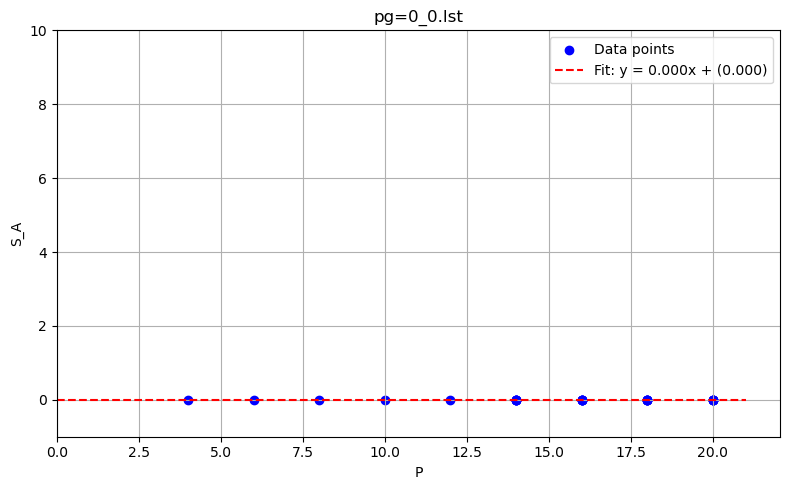

In [5]:
import matplotlib.pyplot as plt
import numpy as np

filename = "pg=0_0.lst"

x = []
y = []

with open(filename, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            cols = line.strip().split('\t')
            if len(cols) >= 2:
                try:
                    x.append(float(cols[0]))
                    y.append(float(cols[1]))
                except ValueError:
                    pass

x = np.array(x)
y = np.array(y)

if len(x) == 0 or len(y) == 0:
    print("データが読み込まれていません。ファイルとフォーマットを確認してください。")
else:
    coeffs = np.polyfit(x, y, deg=1)
    fit_fn = np.poly1d(coeffs)

    x_fit = np.linspace(0, max(x) + 1, 100)

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color='blue', label='Data points')
    plt.plot(x_fit, fit_fn(x_fit), color='red', linestyle='--',
             label=f'Fit: y = {coeffs[0]:.3f}x + ({coeffs[1]:.3f})')
    plt.xlabel('P')
    plt.ylabel('S_A')
    plt.title('pg=0_0.lst')
    plt.grid(True)
    plt.legend()
    plt.xlim(left=0)
    plt.ylim(top=10)
    plt.ylim(bottom=-1)
    plt.tight_layout()
    plt.show()


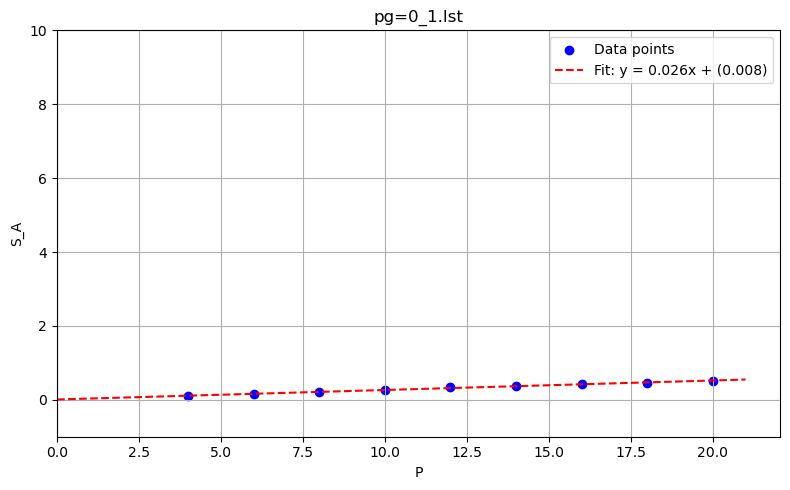

In [6]:
import matplotlib.pyplot as plt
import numpy as np

filename = "averaged_pg=0_1.lst"

x = []
y = []

with open(filename, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            cols = line.strip().split('\t')
            if len(cols) >= 2:
                try:
                    x.append(float(cols[0]))
                    y.append(float(cols[1]))
                except ValueError:
                    pass

x = np.array(x)
y = np.array(y)

if len(x) == 0 or len(y) == 0:
    print("データが読み込まれていません。ファイルとフォーマットを確認してください。")
else:
    coeffs = np.polyfit(x, y, deg=1)
    fit_fn = np.poly1d(coeffs)

    x_fit = np.linspace(0, max(x) + 1, 100)

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color='blue', label='Data points')
    plt.plot(x_fit, fit_fn(x_fit), color='red', linestyle='--',
             label=f'Fit: y = {coeffs[0]:.3f}x + ({coeffs[1]:.3f})')
    plt.xlabel('P')
    plt.ylabel('S_A')
    plt.title('pg=0_1.lst')
    plt.grid(True)
    plt.legend()
    plt.xlim(left=0)
    plt.ylim(top=10)
    plt.ylim(bottom=-1)
    plt.tight_layout()
    plt.show()


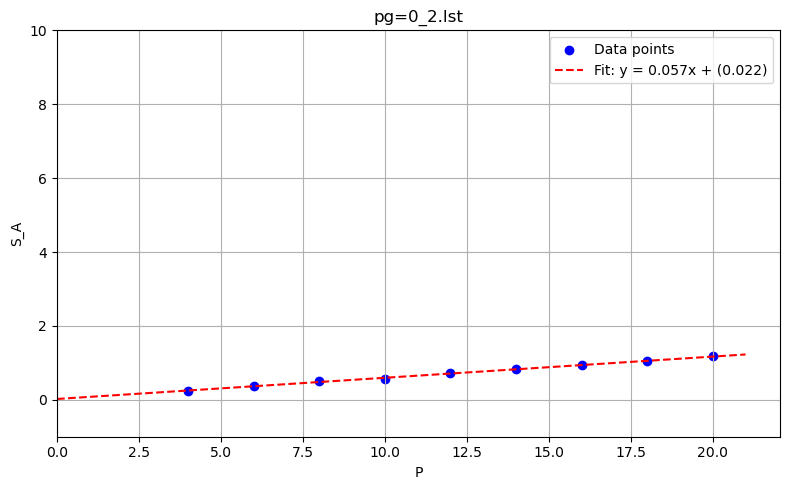

In [7]:
import matplotlib.pyplot as plt
import numpy as np

filename = "averaged_pg=0_2.lst"

x = []
y = []

with open(filename, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            cols = line.strip().split('\t')
            if len(cols) >= 2:
                try:
                    x.append(float(cols[0]))
                    y.append(float(cols[1]))
                except ValueError:
                    pass

x = np.array(x)
y = np.array(y)

if len(x) == 0 or len(y) == 0:
    print("データが読み込まれていません。ファイルとフォーマットを確認してください。")
else:
    coeffs = np.polyfit(x, y, deg=1)
    fit_fn = np.poly1d(coeffs)

    x_fit = np.linspace(0, max(x) + 1, 100)

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color='blue', label='Data points')
    plt.plot(x_fit, fit_fn(x_fit), color='red', linestyle='--',
             label=f'Fit: y = {coeffs[0]:.3f}x + ({coeffs[1]:.3f})')
    plt.xlabel('P')
    plt.ylabel('S_A')
    plt.title('pg=0_2.lst')
    plt.grid(True)
    plt.legend()
    plt.xlim(left=0)
    plt.ylim(top=10)
    plt.ylim(bottom=-1)
    plt.tight_layout()
    plt.show()


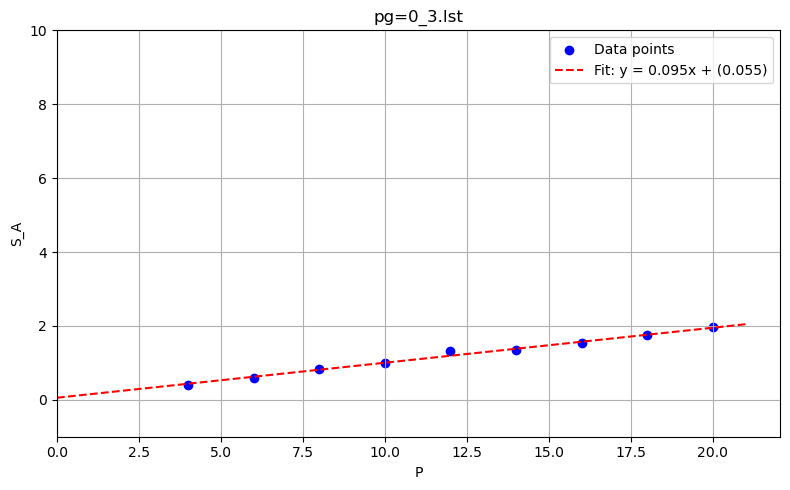

In [8]:
import matplotlib.pyplot as plt
import numpy as np

filename = "averaged_pg=0_3.lst"

x = []
y = []

with open(filename, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            cols = line.strip().split('\t')
            if len(cols) >= 2:
                try:
                    x.append(float(cols[0]))
                    y.append(float(cols[1]))
                except ValueError:
                    pass

x = np.array(x)
y = np.array(y)

if len(x) == 0 or len(y) == 0:
    print("データが読み込まれていません。ファイルとフォーマットを確認してください。")
else:
    coeffs = np.polyfit(x, y, deg=1)
    fit_fn = np.poly1d(coeffs)

    x_fit = np.linspace(0, max(x) + 1, 100)

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color='blue', label='Data points')
    plt.plot(x_fit, fit_fn(x_fit), color='red', linestyle='--',
             label=f'Fit: y = {coeffs[0]:.3f}x + ({coeffs[1]:.3f})')
    plt.xlabel('P')
    plt.ylabel('S_A')
    plt.title('pg=0_3.lst')
    plt.grid(True)
    plt.legend()
    plt.xlim(left=0)
    plt.ylim(top=10)
    plt.ylim(bottom=-1)
    plt.tight_layout()
    plt.show()


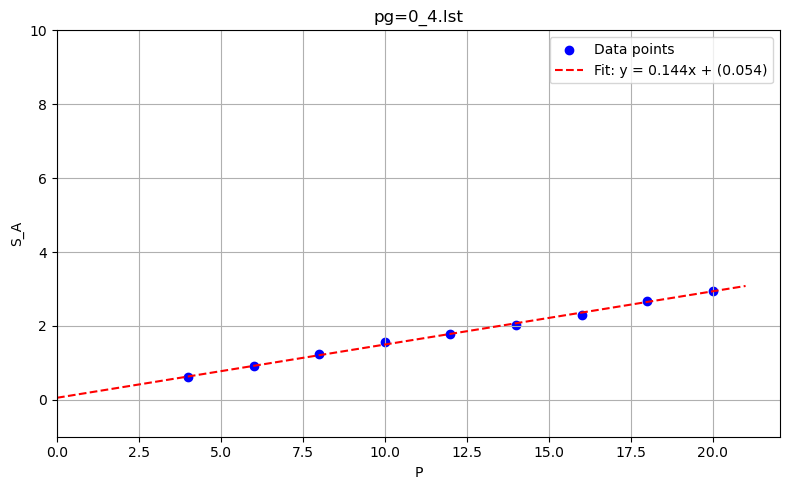

In [9]:
import matplotlib.pyplot as plt
import numpy as np

filename = "averaged_pg=0_4.lst"

x = []
y = []

with open(filename, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            cols = line.strip().split('\t')
            if len(cols) >= 2:
                try:
                    x.append(float(cols[0]))
                    y.append(float(cols[1]))
                except ValueError:
                    pass

x = np.array(x)
y = np.array(y)

if len(x) == 0 or len(y) == 0:
    print("データが読み込まれていません。ファイルとフォーマットを確認してください。")
else:
    coeffs = np.polyfit(x, y, deg=1)
    fit_fn = np.poly1d(coeffs)

    x_fit = np.linspace(0, max(x) + 1, 100)

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color='blue', label='Data points')
    plt.plot(x_fit, fit_fn(x_fit), color='red', linestyle='--',
             label=f'Fit: y = {coeffs[0]:.3f}x + ({coeffs[1]:.3f})')
    plt.xlabel('P')
    plt.ylabel('S_A')
    plt.title('pg=0_4.lst')
    plt.grid(True)
    plt.legend()
    plt.xlim(left=0)
    plt.ylim(top=10)
    plt.ylim(bottom=-1)
    plt.tight_layout()
    plt.show()


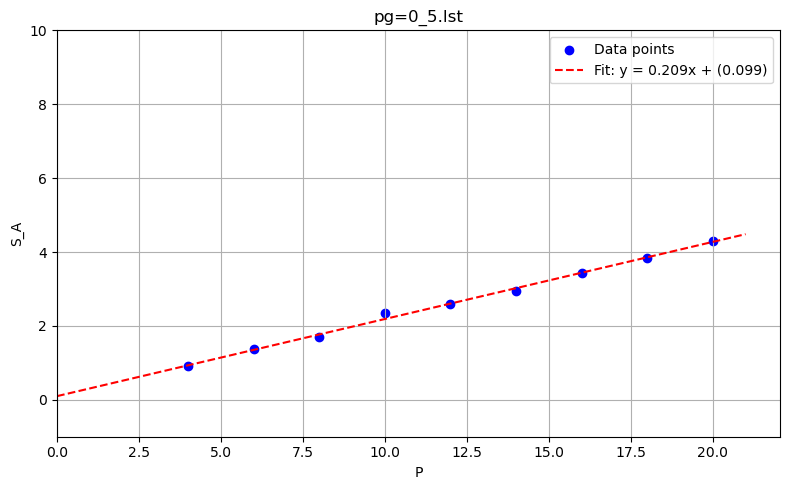

In [10]:
import matplotlib.pyplot as plt
import numpy as np

filename = "averaged_pg=0_5.lst"

x = []
y = []

with open(filename, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            cols = line.strip().split('\t')
            if len(cols) >= 2:
                try:
                    x.append(float(cols[0]))
                    y.append(float(cols[1]))
                except ValueError:
                    pass

x = np.array(x)
y = np.array(y)

if len(x) == 0 or len(y) == 0:
    print("データが読み込まれていません。ファイルとフォーマットを確認してください。")
else:
    coeffs = np.polyfit(x, y, deg=1)
    fit_fn = np.poly1d(coeffs)

    x_fit = np.linspace(0, max(x) + 1, 100)

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color='blue', label='Data points')
    plt.plot(x_fit, fit_fn(x_fit), color='red', linestyle='--',
             label=f'Fit: y = {coeffs[0]:.3f}x + ({coeffs[1]:.3f})')
    plt.xlabel('P')
    plt.ylabel('S_A')
    plt.title('pg=0_5.lst')
    plt.grid(True)
    plt.legend()
    plt.xlim(left=0)
    plt.ylim(top=10)
    plt.ylim(bottom=-1)
    plt.tight_layout()
    plt.show()


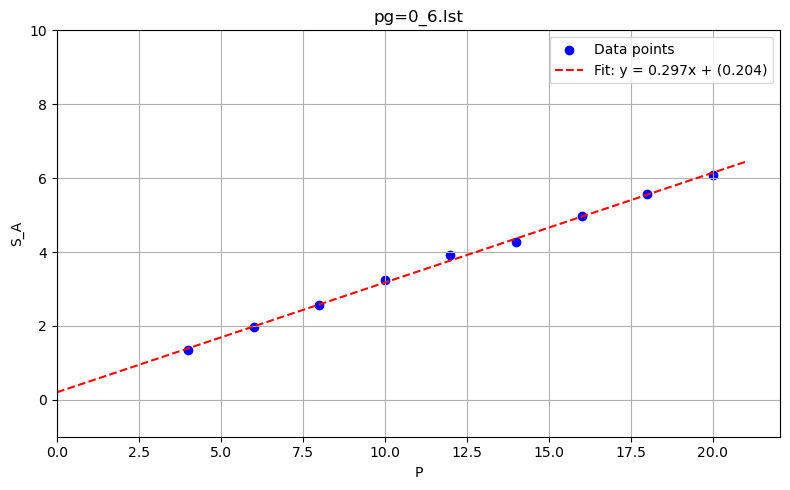

In [11]:
import matplotlib.pyplot as plt
import numpy as np

filename = "averaged_pg=0_6.lst"

x = []
y = []

with open(filename, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            cols = line.strip().split('\t')
            if len(cols) >= 2:
                try:
                    x.append(float(cols[0]))
                    y.append(float(cols[1]))
                except ValueError:
                    pass

x = np.array(x)
y = np.array(y)

if len(x) == 0 or len(y) == 0:
    print("データが読み込まれていません。ファイルとフォーマットを確認してください。")
else:
    coeffs = np.polyfit(x, y, deg=1)
    fit_fn = np.poly1d(coeffs)

    x_fit = np.linspace(0, max(x) + 1, 100)

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color='blue', label='Data points')
    plt.plot(x_fit, fit_fn(x_fit), color='red', linestyle='--',
             label=f'Fit: y = {coeffs[0]:.3f}x + ({coeffs[1]:.3f})')
    plt.xlabel('P')
    plt.ylabel('S_A')
    plt.title('pg=0_6.lst')
    plt.grid(True)
    plt.legend()
    plt.xlim(left=0)
    plt.ylim(top=10)
    plt.ylim(bottom=-1)
    plt.tight_layout()
    plt.show()


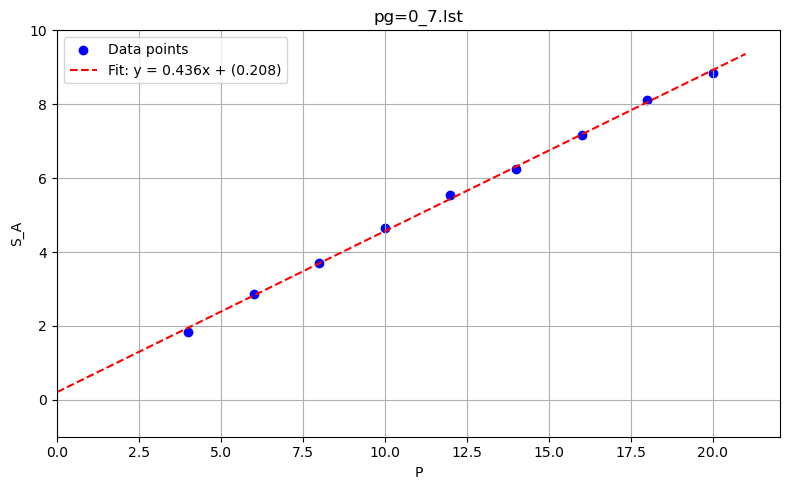

In [12]:
import matplotlib.pyplot as plt
import numpy as np

filename = "averaged_pg=0_7.lst"

x = []
y = []

with open(filename, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            cols = line.strip().split('\t')
            if len(cols) >= 2:
                try:
                    x.append(float(cols[0]))
                    y.append(float(cols[1]))
                except ValueError:
                    pass

x = np.array(x)
y = np.array(y)

if len(x) == 0 or len(y) == 0:
    print("データが読み込まれていません。ファイルとフォーマットを確認してください。")
else:
    coeffs = np.polyfit(x, y, deg=1)
    fit_fn = np.poly1d(coeffs)

    x_fit = np.linspace(0, max(x) + 1, 100)

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color='blue', label='Data points')
    plt.plot(x_fit, fit_fn(x_fit), color='red', linestyle='--',
             label=f'Fit: y = {coeffs[0]:.3f}x + ({coeffs[1]:.3f})')
    plt.xlabel('P')
    plt.ylabel('S_A')
    plt.title('pg=0_7.lst')
    plt.grid(True)
    plt.legend()
    plt.xlim(left=0)
    plt.ylim(top=10)
    plt.ylim(bottom=-1)
    plt.tight_layout()
    plt.show()


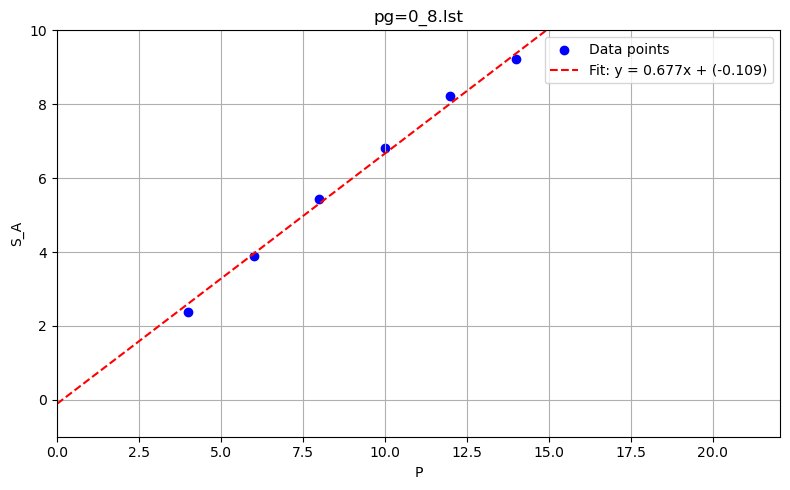

In [15]:
import matplotlib.pyplot as plt
import numpy as np

filename = "averaged_pg=0_8.lst"

x = []
y = []

with open(filename, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            cols = line.strip().split('\t')
            if len(cols) >= 2:
                try:
                    x.append(float(cols[0]))
                    y.append(float(cols[1]))
                except ValueError:
                    pass

x = np.array(x)
y = np.array(y)

if len(x) == 0 or len(y) == 0:
    print("データが読み込まれていません。ファイルとフォーマットを確認してください。")
else:
    coeffs = np.polyfit(x, y, deg=1)
    fit_fn = np.poly1d(coeffs)

    x_fit = np.linspace(0, max(x) + 1, 100)

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color='blue', label='Data points')
    plt.plot(x_fit, fit_fn(x_fit), color='red', linestyle='--',
             label=f'Fit: y = {coeffs[0]:.3f}x + ({coeffs[1]:.3f})')
    plt.xlabel('P')
    plt.ylabel('S_A')
    plt.title('pg=0_8.lst')
    plt.grid(True)
    plt.legend()
    plt.xlim(left=0)
    plt.ylim(top=10)
    plt.ylim(bottom=-1)
    plt.tight_layout()
    plt.show()


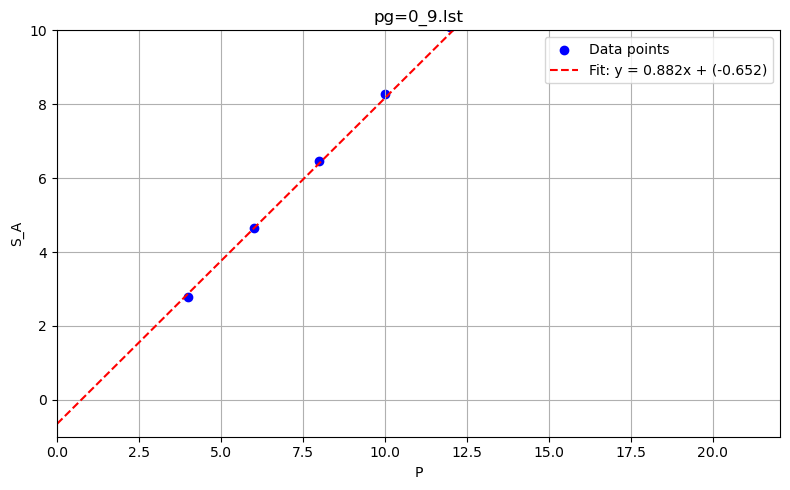

In [16]:
import matplotlib.pyplot as plt
import numpy as np

filename = "averaged_pg=0_9.lst"

x = []
y = []

with open(filename, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            cols = line.strip().split('\t')
            if len(cols) >= 2:
                try:
                    x.append(float(cols[0]))
                    y.append(float(cols[1]))
                except ValueError:
                    pass

x = np.array(x)
y = np.array(y)

if len(x) == 0 or len(y) == 0:
    print("データが読み込まれていません。ファイルとフォーマットを確認してください。")
else:
    coeffs = np.polyfit(x, y, deg=1)
    fit_fn = np.poly1d(coeffs)

    x_fit = np.linspace(0, max(x) + 1, 100)

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color='blue', label='Data points')
    plt.plot(x_fit, fit_fn(x_fit), color='red', linestyle='--',
             label=f'Fit: y = {coeffs[0]:.3f}x + ({coeffs[1]:.3f})')
    plt.xlabel('P')
    plt.ylabel('S_A')
    plt.title('pg=0_9.lst')
    plt.grid(True)
    plt.legend()
    plt.xlim(left=0)
    plt.ylim(top=10)
    plt.ylim(bottom=-1)
    plt.tight_layout()
    plt.show()


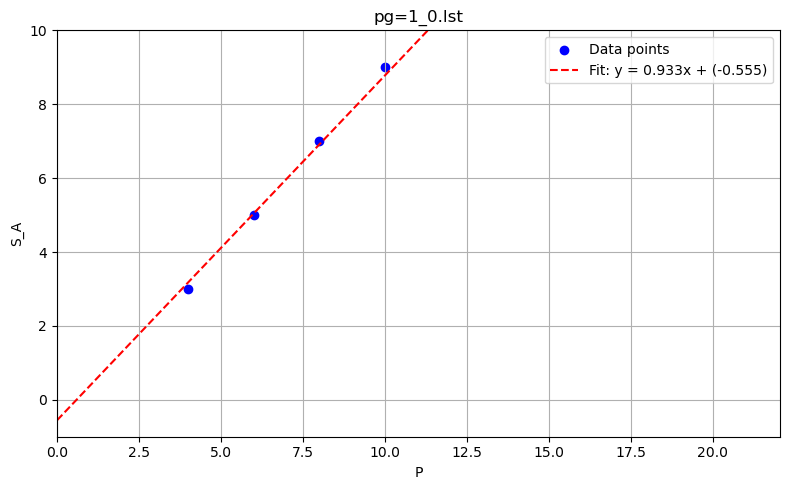

In [17]:
import matplotlib.pyplot as plt
import numpy as np

filename = "averaged_pg=1_0.lst"

x = []
y = []

with open(filename, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            cols = line.strip().split('\t')
            if len(cols) >= 2:
                try:
                    x.append(float(cols[0]))
                    y.append(float(cols[1]))
                except ValueError:
                    pass

x = np.array(x)
y = np.array(y)

if len(x) == 0 or len(y) == 0:
    print("データが読み込まれていません。ファイルとフォーマットを確認してください。")
else:
    coeffs = np.polyfit(x, y, deg=1)
    fit_fn = np.poly1d(coeffs)

    x_fit = np.linspace(0, max(x) + 1, 100)

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color='blue', label='Data points')
    plt.plot(x_fit, fit_fn(x_fit), color='red', linestyle='--',
             label=f'Fit: y = {coeffs[0]:.3f}x + ({coeffs[1]:.3f})')
    plt.xlabel('P')
    plt.ylabel('S_A')
    plt.title('pg=1_0.lst')
    plt.grid(True)
    plt.legend()
    plt.xlim(left=0)
    plt.ylim(top=10)
    plt.ylim(bottom=-1)
    plt.tight_layout()
    plt.show()
